In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import gaussian_kde
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm
import random

# 固定所有随机种子
seed = 32
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"随机种子已固定为 {seed}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("使用设备:", device)

随机种子已固定为 32
使用设备: cuda


In [2]:
# 读取训练数据
df_train = pd.read_csv('real_data.csv')
print("训练数据形状:", df_train.shape)


训练数据形状: (100, 9)


In [3]:
# Cell 3：归一化 + Monte-Carlo扩增训练数据（改进版 - 保证正好10100组）
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
np.random.seed(32)

# 1. 读取原始真实数据
df_train_real = pd.read_csv('real_data.csv')
print("原始XL803真实数据形状:", df_train_real.shape)

# 2. 定义8维特征
feature_cols = ['H3_V_avg', 'H5_V_avg', 'H7_V_avg',
                'H3_I_avg', 'H5_I_avg', 'H7_I_avg',
                'U_THD', 'I_TDD']

# 3. Monte-Carlo扩增（改进：while循环保证正好10000组有效数据）
print("=== 开始Monte-Carlo扩增（保证生成10000组有效模拟数据）===")
real_data = df_train_real[feature_cols].values.astype(np.float32)
n_sim_target = 10000
sim_data_list = []

batch_size = 2000  # 每次生成2000组，提高效率
while len(sim_data_list) < n_sim_target:
    n_needed = n_sim_target - len(sim_data_list)
    n_gen = min(batch_size, n_needed * 2)  # 多生成一些以补偿过滤
    
    sim_batch = np.zeros((n_gen, 8))
    for i in range(8):
        kde = gaussian_kde(real_data[:, i])
        samples = kde.resample(n_gen)[0]
        noise = np.random.normal(0, 0.1, n_gen)
        sim_batch[:, i] = samples + noise
    
    # 计算U_THD和I_TDD（更准确的逻辑）
    sim_batch[:, 6] = np.sqrt(sim_batch[:, 0]**2 + sim_batch[:, 1]**2 + sim_batch[:, 2]**2)
    # I_TDD 使用采样后的谐波 / 真实数据的平均基波电流（符合专利统计特性）
    mean_base_i = real_data[:, 6].mean() if real_data.shape[1] > 6 else 3.0
    sim_batch[:, 7] = np.sqrt(sim_batch[:, 3]**2 + sim_batch[:, 4]**2 + sim_batch[:, 5]**2) / mean_base_i
    
    # 过滤
    mask = (sim_batch[:, 6] < 3.0) & (sim_batch[:, 7] < 4.0)
    valid_batch = sim_batch[mask]
    
    sim_data_list.extend(valid_batch[:n_needed])  # 只取需要的数量
    print(f"  已生成有效模拟数据: {len(sim_data_list)} / {n_sim_target} 组")

sim_data = np.array(sim_data_list[:n_sim_target])

# 合并成正好10100组
df_augmented = pd.concat([df_train_real[feature_cols], pd.DataFrame(sim_data, columns=feature_cols)], ignore_index=True)

# 保存文件
df_augmented.to_csv('train_data_augmented_10100.csv', index=False)

print(f"\n✅ 训练数据扩增完成！总数量: {len(df_augmented)} 组（100真实 + 10000模拟）")
print("已保存: train_data_augmented_10100.csv（可直接用Excel打开查看全部原始值）")

# 4. 归一化（现在用10100组数据）
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
import torch

scaler = MinMaxScaler()
X_train = scaler.fit_transform(df_augmented.values)

# 测试数据归一化（保持不变）
df_test_normal = pd.read_csv('test_real_normal_new_with_base.csv')
df_test_abnormal = pd.read_csv('test_abnormal_fixed.csv')
X_test_normal = scaler.transform(df_test_normal[feature_cols].values)
X_test_abnormal = scaler.transform(df_test_abnormal[feature_cols].values)

tensor_train = torch.FloatTensor(X_train)
dataloader = DataLoader(TensorDataset(tensor_train), batch_size=64, shuffle=True)

print("数据预处理完成（已使用正好10100组扩增数据）")

原始XL803真实数据形状: (100, 9)
=== 开始Monte-Carlo扩增（保证生成10000组有效模拟数据）===
  已生成有效模拟数据: 1895 / 10000 组
  已生成有效模拟数据: 3797 / 10000 组
  已生成有效模拟数据: 5713 / 10000 组
  已生成有效模拟数据: 7614 / 10000 组
  已生成有效模拟数据: 9532 / 10000 组
  已生成有效模拟数据: 10000 / 10000 组

✅ 训练数据扩增完成！总数量: 10100 组（100真实 + 10000模拟）
已保存: train_data_augmented_10100.csv（可直接用Excel打开查看全部原始值）
数据预处理完成（已使用正好10100组扩增数据）


In [4]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(8, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.attention = nn.Sequential(
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Softmax(dim=1)
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 8),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        attn = self.attention(encoded)
        encoded = encoded * attn
        decoded = self.decoder(encoded)
        return decoded

model = Autoencoder().to(device)
print("模型已重新创建")

模型已重新创建


In [5]:
# Cell 5：训练模型（最终稳定版 - 最多3000 + 优化早停机制）

import random

# ==================== 固定所有随机种子 ====================
seed = 32
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"随机种子已固定为 {seed}，确保实验可重复")

# ====================== 从零开始重新创建模型 ======================
model = Autoencoder().to(device)

# ====================== 训练设置 ======================
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)
epochs = 3000
patience = 50           # ← 修改：从100改为50，更及时触发早停
min_delta = 5e-7        # ← 修改：从1e-6改为5e-7，对超低Loss更敏感

loss_history = []
best_loss = float('inf')
patience_counter = 0
early_stop_epoch = None   # 新增：记录实际停止的epoch（方便后续画图标注）

print("开始训练 Autoencoder 模型...\n")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
   
    for batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        batch = batch[0].to(device)
       
        optimizer.zero_grad()
        output = model(batch)
        loss = criterion(output, batch)
       
        loss.backward()
        optimizer.step()
       
        epoch_loss += loss.item()
   
    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
   
    if (epoch + 1) % 50 == 0 or epoch == 0 or epoch == epochs-1:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

    # 早停机制（已优化）
    if avg_loss < best_loss - min_delta:
        best_loss = avg_loss
        patience_counter = 0
    else:
        patience_counter += 1
       
    if patience_counter >= patience:
        early_stop_epoch = epoch + 1
        print(f"\n早停触发！在Epoch {early_stop_epoch}停止训练")
        break

print("\n✅ 训练完成！")
print(f"最终Loss: {loss_history[-1]:.6f}")
if early_stop_epoch:
    print(f"实际早停epoch: {early_stop_epoch}")

随机种子已固定为 32，确保实验可重复
开始训练 Autoencoder 模型...



Epoch 1/3000: 100%|█████████████████████████████████████████████████████████████████| 158/158 [00:00<00:00, 561.44it/s]


Epoch [1/3000], Loss: 0.032506


Epoch 50/3000: 100%|████████████████████████████████████████████████████████████████| 158/158 [00:00<00:00, 848.58it/s]


Epoch [50/3000], Loss: 0.000249


...

Epoch [1050/3000], Loss: 0.000014


Epoch 1100/3000: 100%|██████████████████████████████████████████████████████████████| 158/158 [00:00<00:00, 892.53it/s]


Epoch [1100/3000], Loss: 0.000014


Epoch 1121/3000: 100%|██████████████████████████████████████████████████████████████| 158/158 [00:00<00:00, 838.77it/s]


早停触发！在Epoch 1121停止训练

✅ 训练完成！
最终Loss: 0.000012
实际早停epoch: 1121


In [6]:
# ==================== 第一步：添加 Vanilla AE（基础自编码器）对比 ====================
class VanillaAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(8, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 8),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# 创建并训练 Vanilla AE
print("=== 开始训练 Vanilla AE（基础自编码器）===")
vanilla_model = VanillaAutoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(vanilla_model.parameters(), lr=0.0003)

epochs = 3000
patience = 50
min_delta = 5e-7
vanilla_loss_history = []
best_loss = float('inf')
patience_counter = 0
early_stop_epoch_vanilla = None

for epoch in range(epochs):
    vanilla_model.train()
    epoch_loss = 0.0
    
    for batch in tqdm(dataloader, desc=f"Vanilla AE Epoch {epoch+1}/{epochs}", leave=False):
        batch = batch[0].to(device)
        optimizer.zero_grad()
        output = vanilla_model(batch)
        loss = criterion(output, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(dataloader)
    vanilla_loss_history.append(avg_loss)
    
    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(f"Vanilla AE Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")
    
    # 早停
    if avg_loss < best_loss - min_delta:
        best_loss = avg_loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        early_stop_epoch_vanilla = epoch + 1
        print(f"\nVanilla AE 早停触发！在 Epoch {early_stop_epoch_vanilla} 停止")
        break

print(f"\n✅ Vanilla AE 训练完成！最终 Loss: {vanilla_loss_history[-1]:.6f}")
if early_stop_epoch_vanilla:
    print(f"实际早停 epoch: {early_stop_epoch_vanilla}")

=== 开始训练 Vanilla AE（基础自编码器）===


Vanilla AE Epoch [1/3000], Loss: 0.025760


Vanilla AE Epoch [100/3000], Loss: 0.000063


Vanilla AE Epoch [200/3000], Loss: 0.000061



Vanilla AE 早停触发！在 Epoch 217 停止

✅ Vanilla AE 训练完成！最终 Loss: 0.000061
实际早停 epoch: 217


In [7]:
# ==================== 第二步：两个模型在同一测试集上的对比评估 ====================
print("=== 开始计算两个模型在混合测试集上的性能对比 ===\n")

# 1. 加载测试集（使用你已有的混合测试集）
df_normal = pd.read_csv('test_real_normal_new_with_base.csv')
df_abnormal = pd.read_csv('test_abnormal_mixed_200.csv')   # 200组异常（100轻度 + 100边界）

feature_cols = ['H3_V_avg', 'H5_V_avg', 'H7_V_avg',
                'H3_I_avg', 'H5_I_avg', 'H7_I_avg',
                'U_THD', 'I_TDD']

X_normal = df_normal[feature_cols].values.astype(np.float32)
X_abnormal = df_abnormal[feature_cols].values.astype(np.float32)

X_test = np.vstack([X_normal, X_abnormal])
y_test = np.array([0] * len(X_normal) + [1] * len(X_abnormal))

print(f"测试集规模: {len(X_normal)} 正常 + {len(X_abnormal)} 异常 = {len(X_test)} 样本")

# 2. 归一化（使用训练时的scaler）
X_test_scaled = scaler.transform(X_test)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)

# 3. 计算两个模型的 anomaly scores（重构误差）
model.eval()
vanilla_model.eval()

with torch.no_grad():
    # Attention-enhanced AE
    recon_att = model(X_test_tensor)
    scores_att = torch.mean((X_test_tensor - recon_att)**2, dim=1).cpu().numpy()
    
    # Vanilla AE
    recon_van = vanilla_model(X_test_tensor)
    scores_van = torch.mean((X_test_tensor - recon_van)**2, dim=1).cpu().numpy()

# 4. 计算各项指标（AUC、F1、Precision、Recall）
from sklearn.metrics import roc_curve, auc, f1_score, precision_score, recall_score

def get_metrics(scores, y_true, name="Model"):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    youden_idx = np.argmax(tpr - fpr)
    best_thresh = thresholds[youden_idx]
    
    y_pred = (scores >= best_thresh).astype(int)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    
    print(f"\n{name}:")
    print(f"   AUC          = {roc_auc:.4f}")
    print(f"   F1-score     = {f1:.4f}")
    print(f"   Precision    = {prec:.4f}")
    print(f"   Recall       = {rec:.4f}")
    print(f"   Best threshold = {best_thresh:.5f}")
    return roc_auc, f1, prec, rec, best_thresh

print("=== 性能对比结果 ===")
auc_att, f1_att, prec_att, rec_att, thresh_att = get_metrics(scores_att, y_test, "Attention-AE")
auc_van, f1_van, prec_van, rec_van, thresh_van = get_metrics(scores_van, y_test, "Vanilla AE")

# 5. 输出对比表格（便于直接复制到论文）
import pandas as pd
comparison = pd.DataFrame({
    'Metric': ['AUC', 'F1-score', 'Precision', 'Recall'],
    'Attention-AE': [auc_att, f1_att, prec_att, rec_att],
    'Vanilla AE':   [auc_van, f1_van, prec_van, rec_van]
})
print("\n" + "="*60)
print("               模型性能对比表格")
print("="*60)
print(comparison.round(4))
print("="*60)

# 保存结果（可选）
comparison.to_csv('model_comparison_table.csv', index=False)
print("\n✅ 对比结果已保存为 model_comparison_table.csv")

=== 开始计算两个模型在混合测试集上的性能对比 ===

测试集规模: 200 正常 + 200 异常 = 400 样本
=== 性能对比结果 ===

Attention-AE:
   AUC          = 0.9998
   F1-score     = 0.9924
   Precision    = 1.0000
   Recall       = 0.9850
   Best threshold = 0.00087

Vanilla AE:
   AUC          = 0.9194
   F1-score     = 0.8571
   Precision    = 1.0000
   Recall       = 0.7500
   Best threshold = 0.00137

               模型性能对比表格
      Metric  Attention-AE  Vanilla AE
0        AUC        0.9998      0.9194
1   F1-score        0.9924      0.8571
2  Precision        1.0000      1.0000
3     Recall        0.9850      0.7500

✅ 对比结果已保存为 model_comparison_table.csv


=== 开始 Isolation Forest 对比实验 ===


=== 性能对比结果 ===
Attention-AE:
   AUC       = 0.9998
   F1-score  = 0.9924
   Precision = 1.0000
   Recall    = 0.9850
Vanilla AE:
   AUC       = 0.9194
   F1-score  = 0.8571
   Precision = 1.0000
   Recall    = 0.7500
Isolation Forest:
   AUC       = 0.7873
   F1-score  = 0.6667
   Precision = 1.0000
   Recall    = 0.5000


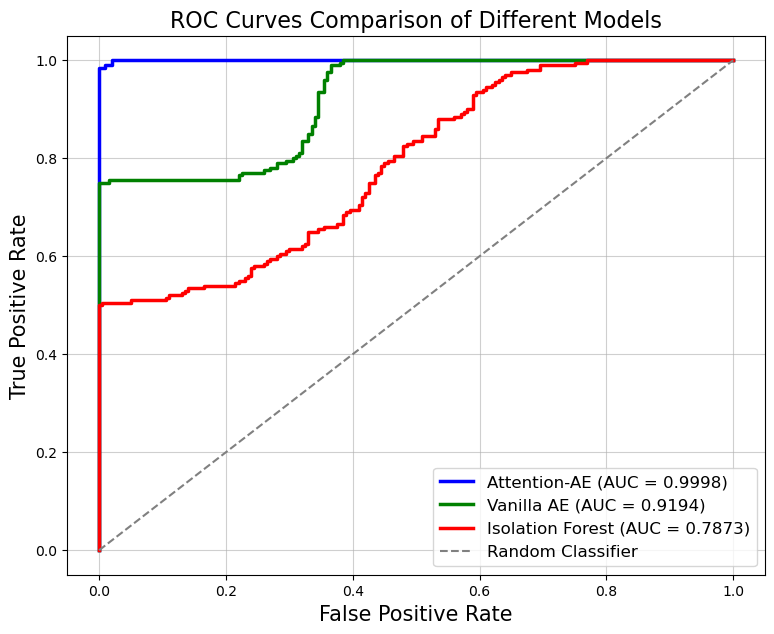


✅ Fig.7 多模型 ROC 对比图已保存！


In [8]:
# ==================== 第三步：Isolation Forest + 三模型 ROC 对比 ====================
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_curve, auc, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

print("=== 开始 Isolation Forest 对比实验 ===\n")

# 1. Isolation Forest 训练（使用训练集）
iso_forest = IsolationForest(contamination=0.01, random_state=32, n_estimators=100)
iso_forest.fit(X_train)   # X_train 是你之前归一化后的10100组训练数据

# 2. 在测试集上计算 anomaly score
scores_iso = -iso_forest.decision_function(X_test_scaled)   # 数值越大越异常

# 3. 计算三个模型的 ROC 曲线和指标
def compute_roc_metrics(scores, y_true, model_name):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    youden_idx = np.argmax(tpr - fpr)
    best_thresh = thresholds[youden_idx]
    y_pred = (scores >= best_thresh).astype(int)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    
    print(f"{model_name}:")
    print(f"   AUC       = {roc_auc:.4f}")
    print(f"   F1-score  = {f1:.4f}")
    print(f"   Precision = {prec:.4f}")
    print(f"   Recall    = {rec:.4f}")
    return fpr, tpr, roc_auc, f1, prec, rec, best_thresh

print("\n=== 性能对比结果 ===")
fpr_att, tpr_att, auc_att, f1_att, prec_att, rec_att, _ = compute_roc_metrics(scores_att, y_test, "Attention-AE")
fpr_van, tpr_van, auc_van, f1_van, prec_van, rec_van, _ = compute_roc_metrics(scores_van, y_test, "Vanilla AE")
fpr_iso, tpr_iso, auc_iso, f1_iso, prec_iso, rec_iso, _ = compute_roc_metrics(scores_iso, y_test, "Isolation Forest")

# 4. 绘制三模型 ROC 曲线对比图（推荐作为 Fig. 7）
plt.figure(figsize=(9, 7))
plt.plot(fpr_att, tpr_att, color='blue',  lw=2.5, label=f'Attention-AE (AUC = {auc_att:.4f})')
plt.plot(fpr_van, tpr_van, color='green', lw=2.5, label=f'Vanilla AE (AUC = {auc_van:.4f})')
plt.plot(fpr_iso, tpr_iso, color='red',   lw=2.5, label=f'Isolation Forest (AUC = {auc_iso:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=15)
plt.ylabel('True Positive Rate', fontsize=15)
plt.title('ROC Curves Comparison of Different Models', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.6)
plt.savefig('Fig7_ROC_Comparison.png', dpi=400, bbox_inches='tight')
plt.show()

print("\n✅ Fig.7 多模型 ROC 对比图已保存！")

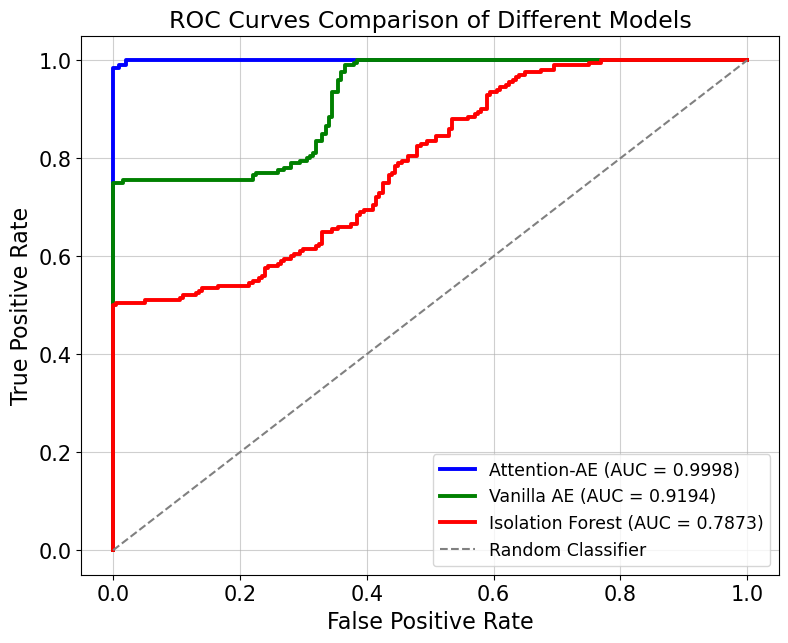

✅ Fig.7 三模型 ROC 对比图已生成（字号已加大）


In [9]:
# Cell for Fig. 7 - ROC comparison - 加大字号版
plt.figure(figsize=(9, 7))
plt.plot(fpr_att, tpr_att, color='blue', lw=2.8, label=f'Attention-AE (AUC = {auc_att:.4f})')
plt.plot(fpr_van, tpr_van, color='green', lw=2.8, label=f'Vanilla AE (AUC = {auc_van:.4f})')
plt.plot(fpr_iso, tpr_iso, color='red', lw=2.8, label=f'Isolation Forest (AUC = {auc_iso:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curves Comparison of Different Models', fontsize=17)
plt.legend(loc="lower right", fontsize=12.5)
plt.grid(True, alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=15)

plt.savefig('Fig7_ROC_Comparison.png', dpi=400, bbox_inches='tight')
plt.show()
print("✅ Fig.7 三模型 ROC 对比图已生成（字号已加大）")

=== 生成三个模型异常分数分布对比图（加大字号版）===


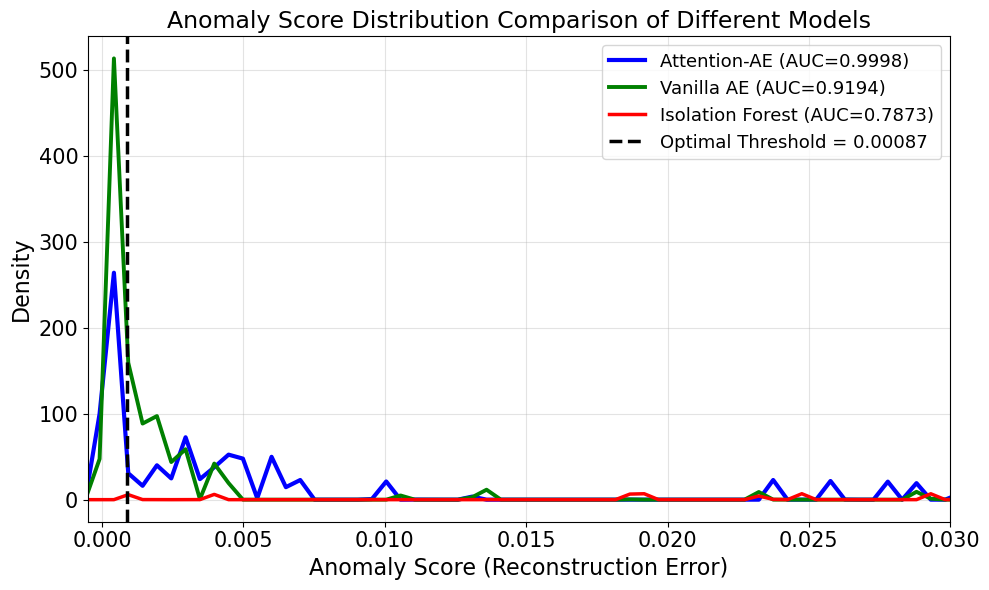

✅ Fig.8 三个模型异常分数分布对比图已生成（字号已加大）


In [10]:
# ==================== 三个模型异常分数分布对比图 (加大字号版) ====================
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

print("=== 生成三个模型异常分数分布对比图（加大字号版）===")

plt.figure(figsize=(10, 6))

# 1. 绘制三个模型的密度曲线
# Attention-AE
kde_att = gaussian_kde(scores_att, bw_method=0.001)
x = np.linspace(min(scores_att.min(), scores_van.min(), scores_iso.min()) - 0.0005,
                max(scores_att.max(), scores_van.max(), scores_iso.max()) + 0.005, 800)
plt.plot(x, kde_att(x), color='blue', lw=3.0, label=f'Attention-AE (AUC={auc_att:.4f})')

# Vanilla AE
kde_van = gaussian_kde(scores_van, bw_method=0.001)
plt.plot(x, kde_van(x), color='green', lw=2.8, label=f'Vanilla AE (AUC={auc_van:.4f})')

# Isolation Forest
kde_iso = gaussian_kde(scores_iso, bw_method=0.002)
plt.plot(x, kde_iso(x), color='red', lw=2.5, label=f'Isolation Forest (AUC={auc_iso:.4f})')

# 2. 标注最佳阈值
best_threshold = 0.00087
plt.axvline(x=best_threshold, color='black', linestyle='--', lw=2.5,
            label=f'Optimal Threshold = {best_threshold:.5f}')

# 3. 美化设置 - 大幅加大字号
plt.xlabel('Anomaly Score (Reconstruction Error)', fontsize=16)
plt.ylabel('Density', fontsize=16)
plt.title('Anomaly Score Distribution Comparison of Different Models', fontsize=17)

plt.legend(fontsize=13, loc='upper right')
plt.grid(True, alpha=0.35)
plt.xlim(-0.0005, 0.03)

# 坐标轴数字字号加大（最关键）
plt.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()

# 保存高清图
plt.savefig('Fig8_Anomaly_Score_Distribution_Comparison.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Fig.8 三个模型异常分数分布对比图已生成（字号已加大）")

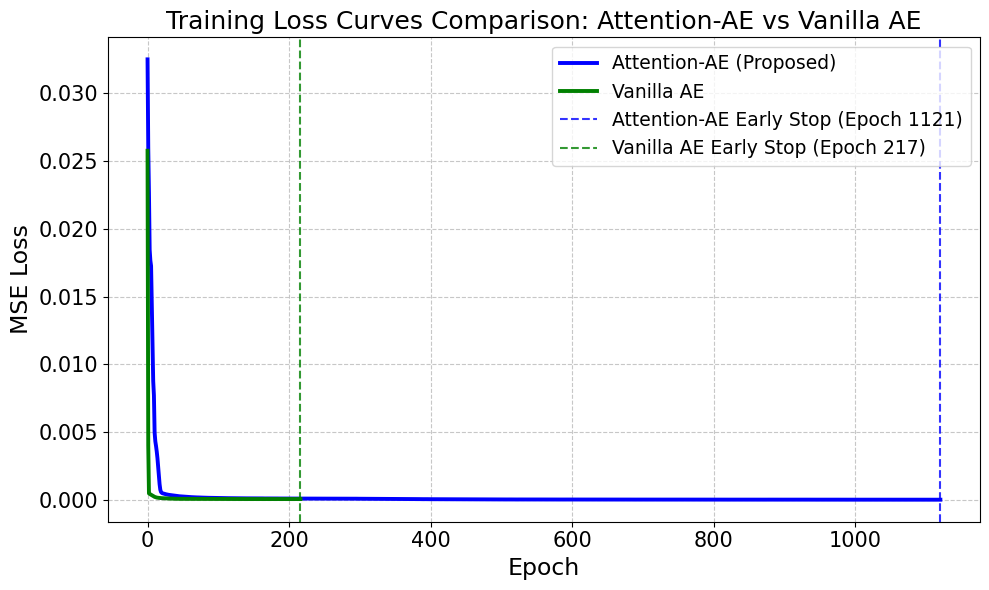

✅ Fig.6 训练损失曲线对比图已生成（字号已加大）


In [11]:
# Cell for Fig. 6 - Training loss comparison - 加大字号版
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(loss_history, label='Attention-AE (Proposed)', color='blue', linewidth=2.8)
plt.plot(vanilla_loss_history, label='Vanilla AE', color='green', linewidth=2.8)

if 'early_stop_epoch' in globals() and early_stop_epoch is not None:
    plt.axvline(x=early_stop_epoch-1, color='blue', linestyle='--', alpha=0.8, 
                label=f'Attention-AE Early Stop (Epoch {early_stop_epoch})')
if 'early_stop_epoch_vanilla' in globals() and early_stop_epoch_vanilla is not None:
    plt.axvline(x=early_stop_epoch_vanilla-1, color='green', linestyle='--', alpha=0.8,
                label=f'Vanilla AE Early Stop (Epoch {early_stop_epoch_vanilla})')

plt.xlabel('Epoch', fontsize=17)
plt.ylabel('MSE Loss', fontsize=17)
plt.title('Training Loss Curves Comparison: Attention-AE vs Vanilla AE', fontsize=18)
plt.legend(fontsize=13.5, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.savefig('Fig6_Loss_Comparison.png', dpi=400, bbox_inches='tight')
plt.show()
print("✅ Fig.6 训练损失曲线对比图已生成（字号已加大）")

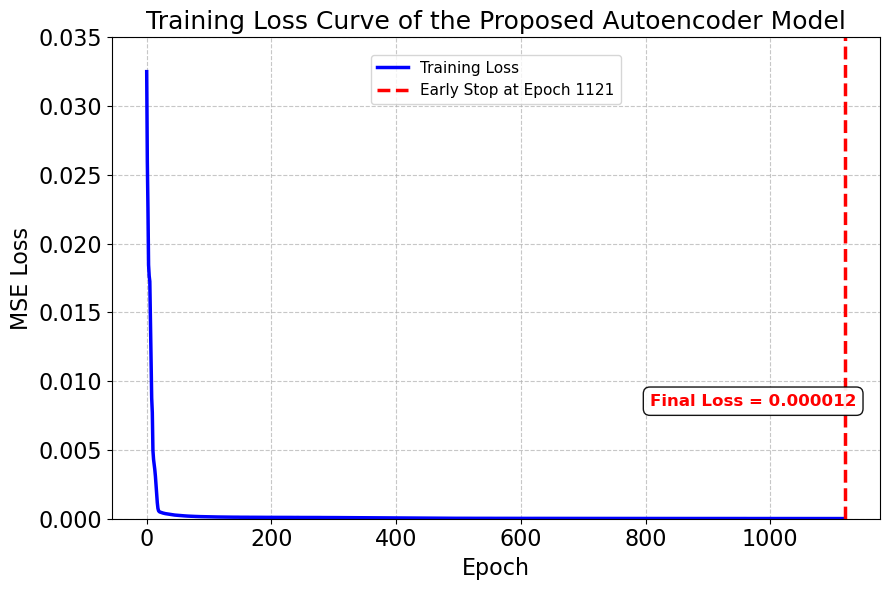

✅ Fig.3 已生成并保存为 Fig3_Training_Loss_Curve.png（400 DPI高清版）
最终Loss值: 0.000012（已标注在图中）
早停点已标注在Epoch 1121


In [12]:
# Cell 6：绘制并保存高清Loss曲线（用于论文 Fig.3 - 坐标数字字号加大版）
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# 绘制Loss曲线
plt.plot(loss_history, label='Training Loss', color='blue', linewidth=2.5)

# 添加早停竖线标注
if 'early_stop_epoch' in globals() and early_stop_epoch is not None:
    plt.axvline(x=early_stop_epoch - 1, color='red', linestyle='--', lw=2.5,
                label=f'Early Stop at Epoch {early_stop_epoch}')

# 添加最终Loss标注（右侧靠下位置，和图例彻底分开）
final_loss = loss_history[-1]
x_text = len(loss_history) * 0.72
y_text = 0.008  # ← 右侧靠下，位置合适
plt.text(x_text, y_text,
         f'Final Loss = {final_loss:.6f}',
         fontsize=12, color='red', fontweight='bold',
         ha='left', va='bottom',
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.92))

# y轴最高值固定为0.035（按你要求）
plt.ylim(0, 0.035)

# 坐标轴标签字号加大
plt.xlabel('Epoch', fontsize=16)  # ← 原13 → 16
plt.ylabel('MSE Loss', fontsize=16)  # ← 原13 → 16

# 标题字号加大
plt.title('Training Loss Curve of the Proposed Autoencoder Model', fontsize=18)  # ← 原14 → 18

# 图例放到最上方中间（上面），字号保持
plt.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 0.98))

# 坐标轴刻度数字（tick labels）字号加大（关键修改）
plt.tick_params(axis='both', which='major', labelsize=16)  # ← 坐标数字从默认10左右改到16

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 保存高清版本（适合直接插入专利/论文）
plt.savefig('Fig3_Training_Loss_Curve.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Fig.3 已生成并保存为 Fig3_Training_Loss_Curve.png（400 DPI高清版）")
print(f"最终Loss值: {final_loss:.6f}（已标注在图中）")
if 'early_stop_epoch' in globals() and early_stop_epoch is not None:
    print(f"早停点已标注在Epoch {early_stop_epoch}")

In [13]:
import pandas as pd
import numpy as np

np.random.seed(32)

def generate_normal_sample(is_boundary=False):
    while True:
        H3_V = np.random.uniform(0.2, 2.0)
        H5_V = np.random.uniform(0.2, 2.0)
        H7_V = np.random.uniform(0.2, 2.0)
        H3_I = np.random.uniform(0.2, 4.0)
        H5_I = np.random.uniform(0.2, 4.0)
        H7_I = np.random.uniform(0.2, 4.0)
        Base_I = np.random.uniform(1.0, 5.0)
        
        U_THD = np.sqrt(H3_V**2 + H5_V**2 + H7_V**2)
        I_TDD = np.sqrt(H3_I**2 + H5_I**2 + H7_I**2) / Base_I
        
        if U_THD >= 3.0 or I_TDD >= 4.0:
            continue
        
        # 如果是边界样本，强制靠近阈值
        if is_boundary:
            if U_THD < 2.7 or I_TDD < 3.6:
                continue
        
        return [H3_V, H5_V, H7_V, H3_I, H5_I, H7_I, Base_I, U_THD, I_TDD]

# 生成200组
normal_data = []
max_uthd = 0
max_itdd = 0

print("正在生成200组合格正常数据（增加边界样本比例）...")

for i in range(200):
    # 30% 的样本故意生成在边界附近
    is_boundary = (i % 10 < 3)   # 每10个里面有3个靠近边界
    sample = generate_normal_sample(is_boundary)
    normal_data.append(sample)
    
    current_uthd = sample[7]
    current_itdd = sample[8]
    
    if current_uthd > max_uthd:
        max_uthd = current_uthd
    if current_itdd > max_itdd:
        max_itdd = current_itdd

df_normal = pd.DataFrame(normal_data, columns=['H3_V_avg', 'H5_V_avg', 'H7_V_avg',
                                               'H3_I_avg', 'H5_I_avg', 'H7_I_avg',
                                               'Base_I', 'U_THD', 'I_TDD'])

df_normal.to_csv('test_real_normal_new_with_base.csv', index=False)

print("✅ 200组严格合格的正常数据已生成并保存（已增加边界样本）")
print("U_THD 范围:", round(df_normal['U_THD'].min(), 3), "~", round(df_normal['U_THD'].max(), 3))
print("I_TDD 范围:", round(df_normal['I_TDD'].min(), 3), "~", round(df_normal['I_TDD'].max(), 3))
print("边界样本比例（U_THD ≥ 2.7%）:", round((df_normal['U_THD'] >= 2.7).mean()*100, 1), "%")
print("边界样本比例（I_TDD ≥ 3.6%）:", round((df_normal['I_TDD'] >= 3.6).mean()*100, 1), "%")

正在生成200组合格正常数据（增加边界样本比例）...
✅ 200组严格合格的正常数据已生成并保存（已增加边界样本）
U_THD 范围: 0.712 ~ 2.988
I_TDD 范围: 0.413 ~ 3.995
边界样本比例（U_THD ≥ 2.7%）: 34.0 %
边界样本比例（I_TDD ≥ 3.6%）: 31.0 %


In [14]:
import pandas as pd
import numpy as np
np.random.seed(32)

# ==================== 直接用 np.random.uniform 生成100组原始轻度异常 ====================
def generate_original_abnormal():
    while True:
        Base_I = np.random.uniform(1.0, 5.0)
        
        # 与原来轻度异常一致的范围
        H3_V = np.random.uniform(0.5, 3.8)
        H5_V = np.random.uniform(0.5, 3.8)
        H7_V = np.random.uniform(0.5, 3.8)
        H3_I = np.random.uniform(0.5, 6.0)
        H5_I = np.random.uniform(0.5, 6.0)
        H7_I = np.random.uniform(0.5, 6.0)
        
        U_THD = np.sqrt(H3_V**2 + H5_V**2 + H7_V**2)
        I_TDD = np.sqrt(H3_I**2 + H5_I**2 + H7_I**2) / Base_I
        
        # 保持原来的异常条件
        if U_THD >= 3.2 and I_TDD >= 4.2:
            return [H3_V, H5_V, H7_V, H3_I, H5_I, H7_I, Base_I, U_THD, I_TDD]

print("正在直接生成100组原始轻度异常样本（保持原始多位精度）...")
original_data = [generate_original_abnormal() for _ in range(100)]

df_original_100 = pd.DataFrame(original_data, columns=[
    'H3_V_avg', 'H5_V_avg', 'H7_V_avg',
    'H3_I_avg', 'H5_I_avg', 'H7_I_avg',
    'Base_I', 'U_THD', 'I_TDD'
])

# 不做任何 round，直接保存（保持 np.random.uniform 的原始精度）
df_original_100.to_csv('test_abnormal_original_100.csv', index=False)

print("✅ 100组原始轻度异常样本生成完成（多位小数，未强制保留3位）")
print(f"已保存为: test_abnormal_original_100.csv")
print("U_THD 范围:", df_original_100['U_THD'].min(), "~", df_original_100['U_THD'].max())
print("\n前5行示例（显示原始多位精度）:")
print(df_original_100.head())

正在直接生成100组原始轻度异常样本（保持原始多位精度）...
✅ 100组原始轻度异常样本生成完成（多位小数，未强制保留3位）
已保存为: test_abnormal_original_100.csv
U_THD 范围: 3.227134131352031 ~ 6.1453544992552

前5行示例（显示原始多位精度）:
   H3_V_avg  H5_V_avg  H7_V_avg  H3_I_avg  H5_I_avg  H7_I_avg    Base_I  \
0  3.478321  2.021169  1.991661  5.996840  1.393331  4.401538  1.371640   
1  0.818219  3.087975  1.909110  1.588735  3.932558  4.021589  1.060000   
2  2.367797  3.641853  3.360755  1.632922  3.861735  2.820503  1.182835   
3  2.618029  2.774718  2.198528  4.869491  3.837868  4.790979  1.730939   
4  2.371860  2.893269  3.278444  5.977654  4.932106  2.410231  1.408996   

      U_THD     I_TDD  
0  4.488937  5.517598  
1  3.721528  5.514010  
2  5.492197  4.272096  
3  4.403028  4.526720  
4  4.974427  5.760032  


In [15]:
import pandas as pd
import numpy as np
np.random.seed(32)

# ==================== 系统化边界异常生成（100组） ====================
def generate_systematic_boundary(boundary_type="U_THD"):
    while True:
        Base_I = np.random.uniform(1.0, 5.0)
        
        H3_V = np.random.uniform(0.2, 1.8)
        H5_V = np.random.uniform(0.2, 1.8)
        H7_V = np.random.uniform(0.2, 1.8)
        H3_I = np.random.uniform(0.2, 3.5)
        H5_I = np.random.uniform(0.2, 3.5)
        H7_I = np.random.uniform(0.2, 3.5)
        
        if boundary_type == "U_THD":
            low_thd = np.sqrt(H3_V**2 + H5_V**2 + H7_V**2)
            high_order = np.random.uniform(0.3, 0.9)
            U_THD = low_thd + high_order
            I_TDD = np.sqrt(H3_I**2 + H5_I**2 + H7_I**2) / Base_I
            if 3.001 <= U_THD <= 3.10 and I_TDD < 4.0:
                return [H3_V, H5_V, H7_V, H3_I, H5_I, H7_I, Base_I, U_THD, I_TDD]
        
        elif boundary_type == "I_TDD":
            U_THD = np.sqrt(H3_V**2 + H5_V**2 + H7_V**2)
            I_TDD = np.random.uniform(4.001, 4.5)
            if U_THD < 3.0:
                return [H3_V, H5_V, H7_V, H3_I, H5_I, H7_I, Base_I, U_THD, I_TDD]

print("正在生成100组系统边界异常样本...")
boundary_data = []
for _ in range(50):
    boundary_data.append(generate_systematic_boundary("U_THD"))
for _ in range(50):
    boundary_data.append(generate_systematic_boundary("I_TDD"))

df_boundary_100 = pd.DataFrame(boundary_data, columns=[
    'H3_V_avg', 'H5_V_avg', 'H7_V_avg',
    'H3_I_avg', 'H5_I_avg', 'H7_I_avg',
    'Base_I', 'U_THD', 'I_TDD'
])

df_boundary_100.to_csv('test_abnormal_boundary_100.csv', index=False)
print("✅ 100组系统边界异常样本生成完成！")
print(f"已保存为: test_abnormal_boundary_100.csv")
print("U_THD 范围:", round(df_boundary_100['U_THD'].min(), 4), "~", round(df_boundary_100['U_THD'].max(), 4))

正在生成100组系统边界异常样本...
✅ 100组系统边界异常样本生成完成！
已保存为: test_abnormal_boundary_100.csv
U_THD 范围: 0.7257 ~ 3.0997


In [16]:
# ==================== 生成100+100混合测试集 ====================
import pandas as pd

# 读取已生成的两个文件
df_original_100 = pd.read_csv('test_abnormal_original_100.csv')
df_boundary_100 = pd.read_csv('test_abnormal_boundary_100.csv')

# 合并成200组（100 + 100）
df_mixed_200 = pd.concat([df_original_100, df_boundary_100], ignore_index=True)

# 保存混合测试集
df_mixed_200.to_csv('test_abnormal_mixed_200.csv', index=False)

print("✅ 100+100混合测试集生成完成！")
print(f"总异常样本数: {len(df_mixed_200)}")
print("U_THD 范围:", df_mixed_200['U_THD'].min(), "~", df_mixed_200['U_THD'].max())
print("边界样本比例:", round((df_mixed_200['U_THD'] < 3.2).mean() * 100, 1), "%")
print("文件已保存为: test_abnormal_mixed_200.csv")

✅ 100+100混合测试集生成完成！
总异常样本数: 200
U_THD 范围: 0.7256825544315525 ~ 6.1453544992552
边界样本比例: 50.0 %
文件已保存为: test_abnormal_mixed_200.csv


=== 生成 Fig.4 ROC曲线（200正常 + 100原始轻度异常 + 100边界异常）===

正常样本数量: 200 | 异常样本数量: 200


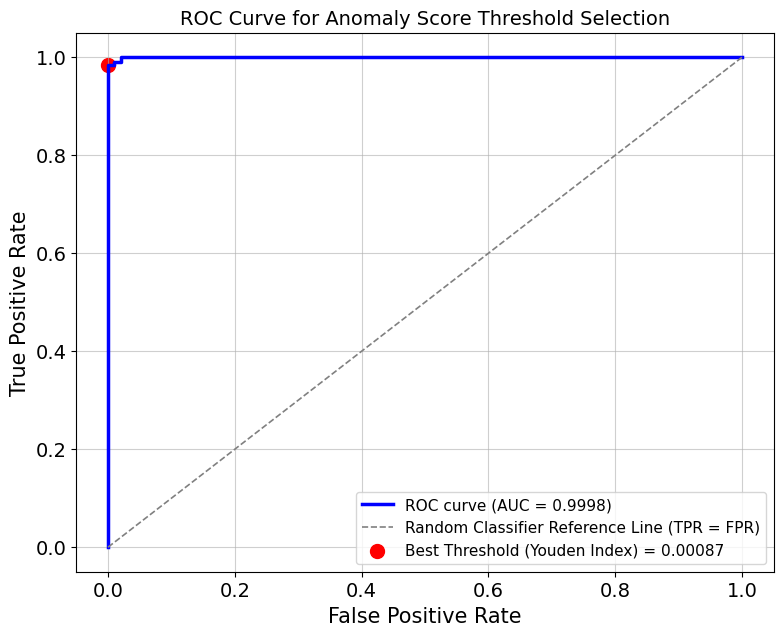


✅ Fig.4 已生成并保存
ROC-AUC = 0.9998
最佳阈值 (Youden Index) = 0.00087


In [17]:
# Cell 7：生成 Fig.4 ROC曲线（使用100+100混合测试集）
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("=== 生成 Fig.4 ROC曲线（200正常 + 100原始轻度异常 + 100边界异常）===\n")

# 1. 读取数据
df_normal = pd.read_csv('test_real_normal_new_with_base.csv')
df_abnormal = pd.read_csv('test_abnormal_mixed_200.csv')   # 100+100混合测试集

feature_cols = ['H3_V_avg', 'H5_V_avg', 'H7_V_avg',
                'H3_I_avg', 'H5_I_avg', 'H7_I_avg',
                'U_THD', 'I_TDD']

X_normal = df_normal[feature_cols].values.astype(np.float32)
X_abnormal = df_abnormal[feature_cols].values.astype(np.float32)

print(f"正常样本数量: {len(X_normal)} | 异常样本数量: {len(X_abnormal)}")

# 2. 合并测试集
X_test = np.vstack([X_normal, X_abnormal])
y_test = np.array([0] * len(X_normal) + [1] * len(X_abnormal))

# 3. 归一化（使用训练时拟合的scaler）
X_test_scaled = scaler.transform(X_test)

# 4. 计算异常分数
model.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
    reconstructed = model(X_test_tensor)
    anomaly_scores = torch.mean((X_test_tensor - reconstructed)**2, dim=1).cpu().numpy()

# 5. 绘制ROC曲线
fpr, tpr, thresholds = roc_curve(y_test, anomaly_scores)
roc_auc = auc(fpr, tpr)
youden_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[youden_idx]

plt.figure(figsize=(9, 7))
plt.plot(fpr, tpr, color='blue', lw=2.5,
         label='ROC curve (AUC = {:.4f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='gray', lw=1.2, linestyle='--',
         label='Random Classifier Reference Line (TPR = FPR)')
plt.scatter(fpr[youden_idx], tpr[youden_idx], color='red', s=100,
            label='Best Threshold (Youden Index) = {:.5f}'.format(best_threshold))

plt.xlabel('False Positive Rate', fontsize=15)
plt.ylabel('True Positive Rate', fontsize=15)
plt.title('ROC Curve for Anomaly Score Threshold Selection', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.6)

# 保存文件名更新为混合测试集
plt.savefig('Fig4_ROC_Curve_mixed_200.png', dpi=400, bbox_inches='tight')
plt.show()

print(f"\n✅ Fig.4 已生成并保存")
print(f"ROC-AUC = {roc_auc:.4f}")
print(f"最佳阈值 (Youden Index) = {best_threshold:.5f}")

=== 开始 ROC 曲线对比实验（仅 Attention-AE vs Vanilla AE） ===


=== 性能对比结果 ===
Attention-AE:
 AUC = 0.9998
 F1-score = 0.9924
 Precision = 1.0000
 Recall = 0.9850
Vanilla AE:
 AUC = 0.9194
 F1-score = 0.8571
 Precision = 1.0000
 Recall = 0.7500


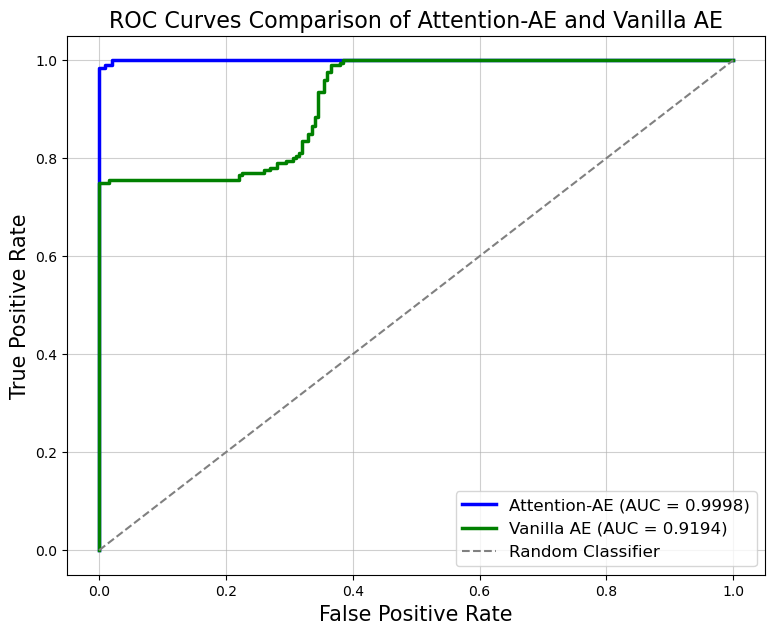


✅ Fig.7 双模型 ROC 对比图已保存！（仅 Attention-AE 和 Vanilla AE）


In [18]:
# ==================== 第三步：只显示 Attention-AE 和 Vanilla AE 的 ROC 对比 ====================
from sklearn.metrics import roc_curve, auc, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

print("=== 开始 ROC 曲线对比实验（仅 Attention-AE vs Vanilla AE） ===\n")

# 复用前面已经计算好的 scores_att 和 scores_van（如果前面 cell 已运行过）
# 如果没有，请确保前面已经计算了 scores_att 和 scores_van

def compute_roc_metrics(scores, y_true, model_name):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    youden_idx = np.argmax(tpr - fpr)
    best_thresh = thresholds[youden_idx]
    y_pred = (scores >= best_thresh).astype(int)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
   
    print(f"{model_name}:")
    print(f" AUC = {roc_auc:.4f}")
    print(f" F1-score = {f1:.4f}")
    print(f" Precision = {prec:.4f}")
    print(f" Recall = {rec:.4f}")
    return fpr, tpr, roc_auc, f1, prec, rec, best_thresh

print("\n=== 性能对比结果 ===")
fpr_att, tpr_att, auc_att, f1_att, prec_att, rec_att, _ = compute_roc_metrics(scores_att, y_test, "Attention-AE")
fpr_van, tpr_van, auc_van, f1_van, prec_van, rec_van, _ = compute_roc_metrics(scores_van, y_test, "Vanilla AE")

# 4. 绘制仅两个模型的 ROC 曲线对比图（推荐作为 Fig. 7）
plt.figure(figsize=(9, 7))
plt.plot(fpr_att, tpr_att, color='blue', lw=2.5, label=f'Attention-AE (AUC = {auc_att:.4f})')
plt.plot(fpr_van, tpr_van, color='green', lw=2.5, label=f'Vanilla AE (AUC = {auc_van:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=15)
plt.ylabel('True Positive Rate', fontsize=15)
plt.title('ROC Curves Comparison of Attention-AE and Vanilla AE', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.6)
plt.savefig('Fig7_ROC_Comparison.png', dpi=400, bbox_inches='tight')
plt.show()

print("\n✅ Fig.7 双模型 ROC 对比图已保存！（仅 Attention-AE 和 Vanilla AE）")

=== 开始 ROC 曲线对比实验（仅 Attention-AE vs Vanilla AE） ===


=== 性能对比结果 ===
Attention-AE:
 AUC = 0.9998
 F1-score = 0.9924
 Precision = 1.0000
 Recall = 0.9850
Vanilla AE:
 AUC = 0.9194
 F1-score = 0.8571
 Precision = 1.0000
 Recall = 0.7500


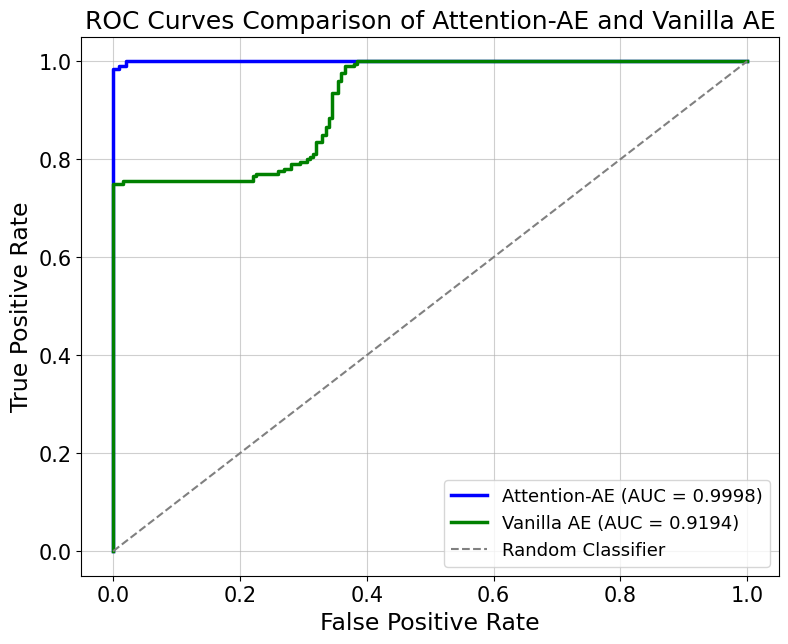


✅ Fig.7 双模型 ROC 对比图已保存！（横纵坐标字号已调大）


In [19]:
# ==================== 第三步：只显示 Attention-AE 和 Vanilla AE 的 ROC 对比 ====================
from sklearn.metrics import roc_curve, auc, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

print("=== 开始 ROC 曲线对比实验（仅 Attention-AE vs Vanilla AE） ===\n")

def compute_roc_metrics(scores, y_true, model_name):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    youden_idx = np.argmax(tpr - fpr)
    best_thresh = thresholds[youden_idx]
    y_pred = (scores >= best_thresh).astype(int)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
   
    print(f"{model_name}:")
    print(f" AUC = {roc_auc:.4f}")
    print(f" F1-score = {f1:.4f}")
    print(f" Precision = {prec:.4f}")
    print(f" Recall = {rec:.4f}")
    return fpr, tpr, roc_auc, f1, prec, rec, best_thresh

print("\n=== 性能对比结果 ===")
fpr_att, tpr_att, auc_att, f1_att, prec_att, rec_att, _ = compute_roc_metrics(scores_att, y_test, "Attention-AE")
fpr_van, tpr_van, auc_van, f1_van, prec_van, rec_van, _ = compute_roc_metrics(scores_van, y_test, "Vanilla AE")

# 4. 绘制仅两个模型的 ROC 曲线对比图（横纵坐标字号已调大）
plt.figure(figsize=(9, 7))
plt.plot(fpr_att, tpr_att, color='blue', lw=2.5, label=f'Attention-AE (AUC = {auc_att:.4f})')
plt.plot(fpr_van, tpr_van, color='green', lw=2.5, label=f'Vanilla AE (AUC = {auc_van:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=17)
plt.ylabel('True Positive Rate', fontsize=17)
plt.title('ROC Curves Comparison of Attention-AE and Vanilla AE', fontsize=18)

plt.tick_params(axis='both', which='major', labelsize=15)   # 刻度字号调大
plt.legend(loc="lower right", fontsize=13)

plt.grid(True, alpha=0.6)
plt.savefig('Fig7_ROC_Comparison.png', dpi=400, bbox_inches='tight')
plt.show()

print("\n✅ Fig.7 双模型 ROC 对比图已保存！（横纵坐标字号已调大）")

=== 生成 Fig.5 单模型异常分数分布图 ===

正常样本数: 200 | 异常样本数: 200
最佳阈值: 0.00087


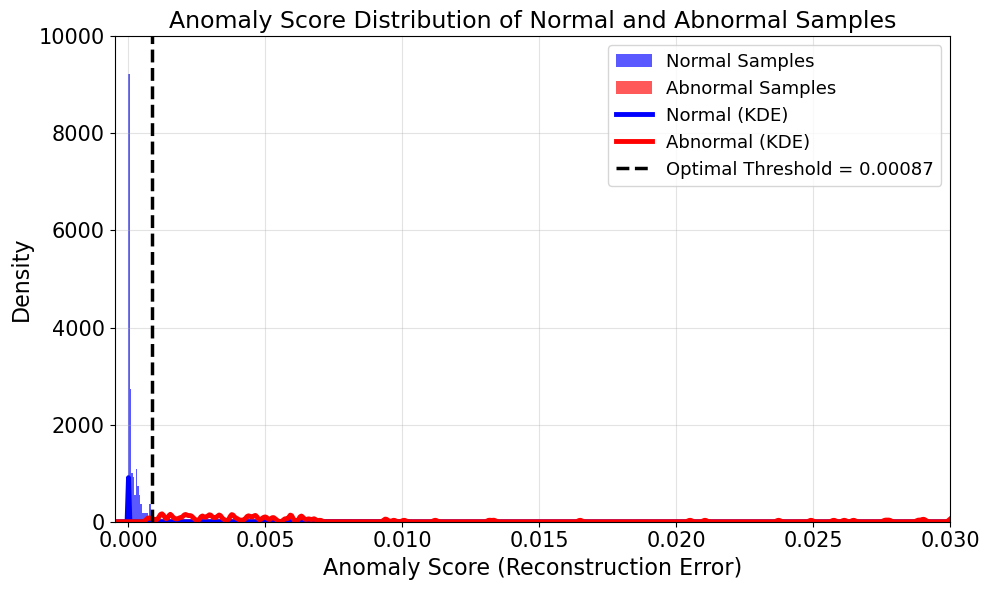

✅ Fig.5 已生成并保存为 Fig5_Anomaly_Score_Distribution.png


In [22]:
# ==================== Fig.5：异常分数分布图（完整版） ====================
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

print("=== 生成 Fig.5 单模型异常分数分布图 ===\n")

# ----- 1. 准备数据 -----
# 假设已经运行过 Cell 7，存在以下变量：
#   anomaly_scores: 所有测试集的异常分数
#   y_test: 测试集标签 (0=正常, 1=异常)
#   best_threshold: 最佳阈值

# 拆分正常和异常的分数
scores_normal = anomaly_scores[y_test == 0]
scores_abnormal = anomaly_scores[y_test == 1]

print(f"正常样本数: {len(scores_normal)} | 异常样本数: {len(scores_abnormal)}")
print(f"最佳阈值: {best_threshold:.5f}")

# ----- 2. 绘图 -----
plt.figure(figsize=(10, 6))

# 直方图（使用 density=True 归一化为概率密度）
plt.hist(scores_normal, bins=15, alpha=0.65, color='blue', label='Normal Samples', density=True)
plt.hist(scores_abnormal, bins=25, alpha=0.65, color='red', label='Abnormal Samples', density=True)

# 核密度曲线（平滑版）
kde_n = gaussian_kde(scores_normal, bw_method=0.0012)
kde_a = gaussian_kde(scores_abnormal, bw_method=0.0012)
x = np.linspace(-0.0005, 0.03, 600)
plt.plot(x, kde_n(x), color='blue', lw=3.5, label='Normal (KDE)')
plt.plot(x, kde_a(x), color='red', lw=3.5, label='Abnormal (KDE)')

# 最佳阈值竖线
plt.axvline(x=best_threshold, color='black', linestyle='--', lw=2.5,
            label=f'Optimal Threshold = {best_threshold:.5f}')

# 坐标轴与样式
plt.xlabel('Anomaly Score (Reconstruction Error)', fontsize=16)
plt.ylabel('Density', fontsize=16)
plt.title('Anomaly Score Distribution of Normal and Abnormal Samples', fontsize=17)
plt.legend(fontsize=13, loc='upper right')
plt.grid(True, alpha=0.35)
plt.xlim(-0.0005, 0.03)
plt.ylim(0, 10000)
plt.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.savefig('Fig5_Anomaly_Score_Distribution.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Fig.5 已生成并保存为 Fig5_Anomaly_Score_Distribution.png")

=== 生成 Fig.6 重构效果对比图（200正常 + 100原始轻度异常 + 100边界异常）===

正常样本数量: 200 | 异常样本数量: 200


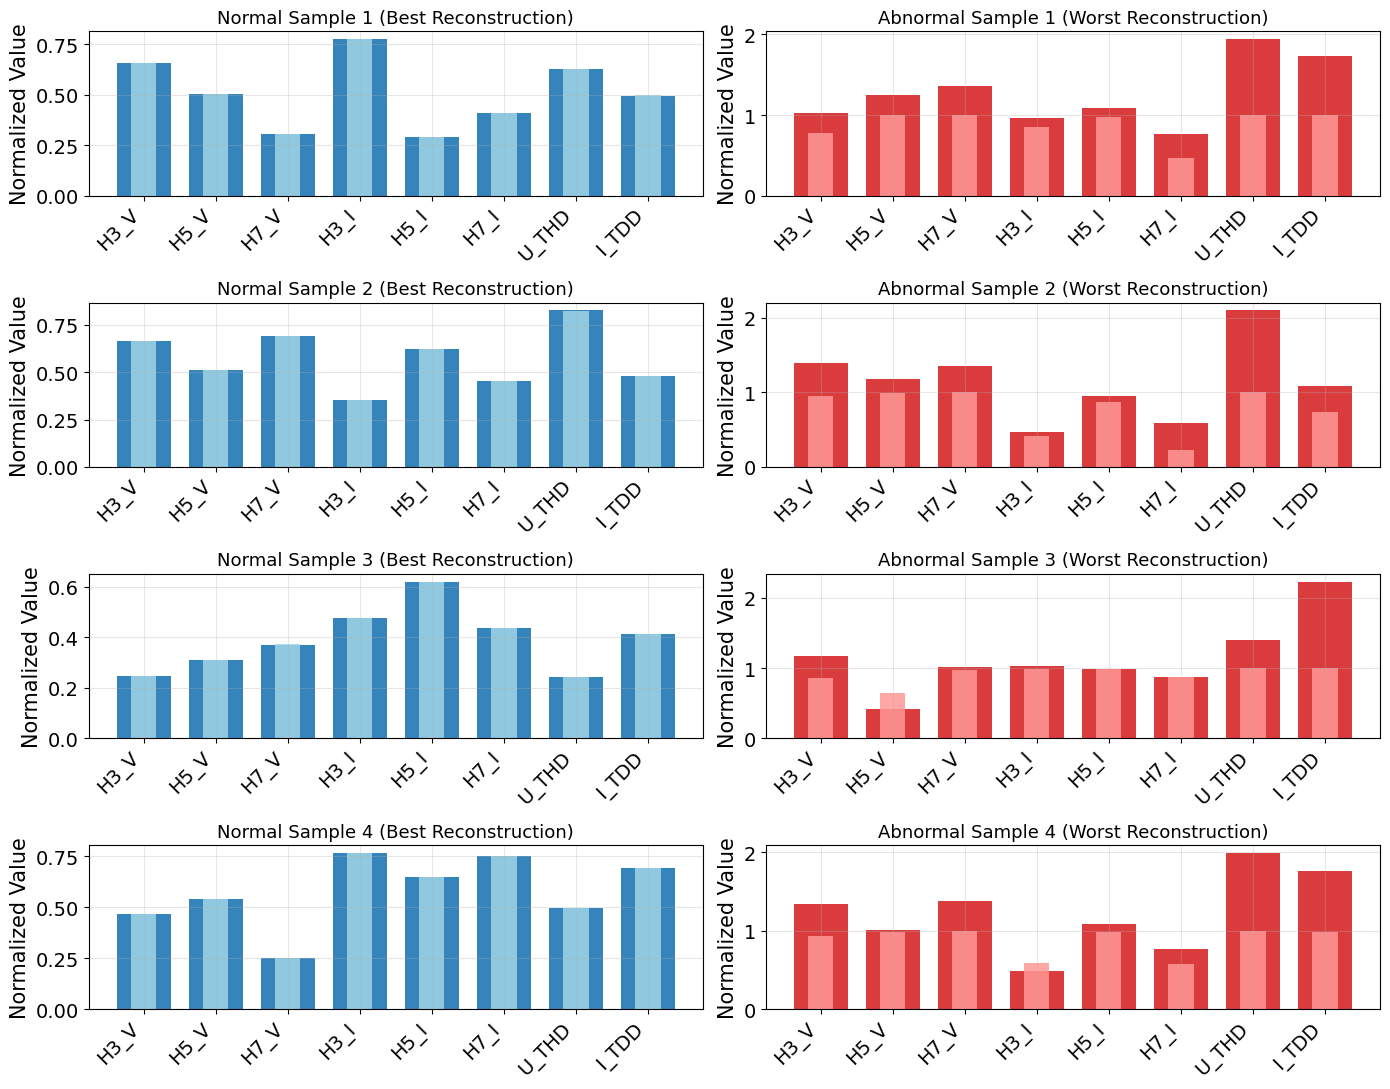

✅ Fig.6 已生成并保存为 Fig6_Reconstruction_Examples_mixed_200.png（高清版）


In [23]:
# Cell 9：生成 Fig.6 重构效果可视化（使用100+100混合测试集）
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

print("=== 生成 Fig.6 重构效果对比图（200正常 + 100原始轻度异常 + 100边界异常）===\n")

# 1. 读取数据（只取8列特征，丢弃Base_I）
feature_cols = ['H3_V_avg', 'H5_V_avg', 'H7_V_avg',
                'H3_I_avg', 'H5_I_avg', 'H7_I_avg',
                'U_THD', 'I_TDD']

df_normal = pd.read_csv('test_real_normal_new_with_base.csv')
df_abnormal = pd.read_csv('test_abnormal_mixed_200.csv')   # ← 已修改为最新混合测试集

X_normal = df_normal[feature_cols].values.astype(np.float32)
X_abnormal = df_abnormal[feature_cols].values.astype(np.float32)

print(f"正常样本数量: {len(X_normal)} | 异常样本数量: {len(X_abnormal)}")

# 2. 计算所有样本的重构误差
model.eval()
with torch.no_grad():
    # 正常样本
    X_n_scaled = scaler.transform(X_normal)
    X_n_tensor = torch.FloatTensor(X_n_scaled).to(device)
    recon_n = model(X_n_tensor).cpu().numpy()
    error_normal = np.mean((X_n_scaled - recon_n)**2, axis=1)
  
    # 异常样本
    X_a_scaled = scaler.transform(X_abnormal)
    X_a_tensor = torch.FloatTensor(X_a_scaled).to(device)
    recon_a = model(X_a_tensor).cpu().numpy()
    error_abnormal = np.mean((X_a_scaled - recon_a)**2, axis=1)

# 3. 选样
best_normal_idx = np.argsort(error_normal)[:4]   # 正常：重构误差最小的4个
worst_abnormal_idx = np.argsort(error_abnormal)[-4:]  # 异常：重构误差最大的4个

# 4. 绘制
fig, axes = plt.subplots(4, 2, figsize=(14, 11))
feature_names = ['H3_V', 'H5_V', 'H7_V', 'H3_I', 'H5_I', 'H7_I', 'U_THD', 'I_TDD']

for i in range(4):
    # 左侧：正常样本（几乎完全重合）
    idx_n = best_normal_idx[i]
    axes[i, 0].bar(range(8), X_n_scaled[idx_n], alpha=0.9, color='#1f77b4', width=0.75)
    axes[i, 0].bar(range(8), recon_n[idx_n], alpha=0.85, color='#a1d6e6', width=0.35)
    axes[i, 0].set_title(f'Normal Sample {i+1} (Best Reconstruction)', fontsize=13)
    axes[i, 0].set_ylabel('Normalized Value', fontsize=15)
    axes[i, 0].set_xticks(range(8))
    axes[i, 0].set_xticklabels(feature_names, rotation=45, ha='right', fontsize=14)
    axes[i, 0].tick_params(axis='y', labelsize=14)
    axes[i, 0].grid(True, alpha=0.3)
  
    # 右侧：异常样本（差异最大）
    idx_a = worst_abnormal_idx[i]
    axes[i, 1].bar(range(8), X_a_scaled[idx_a], alpha=0.9, color='#d62728', width=0.75)
    axes[i, 1].bar(range(8), recon_a[idx_a], alpha=0.85, color='#ff9896', width=0.35)
    axes[i, 1].set_title(f'Abnormal Sample {i+1} (Worst Reconstruction)', fontsize=13)
    axes[i, 1].set_ylabel('Normalized Value', fontsize=15)
    axes[i, 1].set_xticks(range(8))
    axes[i, 1].set_xticklabels(feature_names, rotation=45, ha='right', fontsize=14)
    axes[i, 1].tick_params(axis='y', labelsize=14)
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Fig6_Reconstruction_Examples_mixed_200.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Fig.6 已生成并保存为 Fig6_Reconstruction_Examples_mixed_200.png（高清版）")

In [24]:
# ==================== OC-SVM (One-Class SVM) 对比实验 ====================
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_curve, auc, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

print("=== 开始 OC-SVM 对比实验 ===\n")

# 1. 训练 OC-SVM（使用归一化后的训练集 X_train）
# nu: 训练集中异常比例的上界（训练集全为正常样本，设0.01~0.02）
# kernel='rbf' 适合非线性分布，gamma='scale' 自动适配
ocsvm = OneClassSVM(nu=0.01, kernel='rbf', gamma='scale')
ocsvm.fit(X_train)   # X_train 已归一化，shape: (10100, 8)

# 2. 在测试集上计算异常分数
# decision_function: 正值表示正常，负值表示异常
# 取负号使其变为"越大越异常"，与您的 Attention-AE 方向一致
scores_ocsvm = -ocsvm.decision_function(X_test_scaled)

# 3. 计算评估指标
def compute_metrics(scores, y_true, model_name):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    youden_idx = np.argmax(tpr - fpr)
    best_thresh = thresholds[youden_idx]
    y_pred = (scores >= best_thresh).astype(int)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    
    print(f"\n{model_name}:")
    print(f"   AUC       = {roc_auc:.4f}")
    print(f"   F1-score  = {f1:.4f}")
    print(f"   Precision = {prec:.4f}")
    print(f"   Recall    = {rec:.4f}")
    print(f"   Best threshold = {best_thresh:.6f}")
    return fpr, tpr, roc_auc, f1, prec, rec, best_thresh

# 4. 计算并输出结果
print("\n=== 性能对比结果 ===")
fpr_ocs, tpr_ocs, auc_ocs, f1_ocs, prec_ocs, rec_ocs, thresh_ocs = compute_metrics(
    scores_ocsvm, y_test, "OC-SVM"
)

# 5. 汇总对比表格
import pandas as pd
comparison_updated = pd.DataFrame({
    'Metric': ['AUC', 'F1-score', 'Precision', 'Recall'],
    'Attention-AE': [auc_att, f1_att, prec_att, rec_att],
    'Vanilla AE': [auc_van, f1_van, prec_van, rec_van],
    'Isolation Forest': [auc_iso, f1_iso, prec_iso, rec_iso],
    'OC-SVM': [auc_ocs, f1_ocs, prec_ocs, rec_ocs]
})
print("\n" + "="*70)
print("               四模型性能对比表格")
print("="*70)
print(comparison_updated.round(4))
print("="*70)

# 6. 可选：保存对比结果
comparison_updated.to_csv('model_comparison_4models.csv', index=False)
print("\n✅ 四模型对比结果已保存为 model_comparison_4models.csv")

=== 开始 OC-SVM 对比实验 ===


=== 性能对比结果 ===

OC-SVM:
   AUC       = 0.8437
   F1-score  = 0.8069
   Precision = 0.9524
   Recall    = 0.7000
   Best threshold = 0.940163

               四模型性能对比表格
      Metric  Attention-AE  Vanilla AE  Isolation Forest  OC-SVM
0        AUC        0.9998      0.9194            0.7873  0.8437
1   F1-score        0.9924      0.8571            0.6667  0.8069
2  Precision        1.0000      1.0000            1.0000  0.9524
3     Recall        0.9850      0.7500            0.5000  0.7000

✅ 四模型对比结果已保存为 model_comparison_4models.csv


=== 生成四模型 ROC 曲线对比图（含 OC-SVM）===


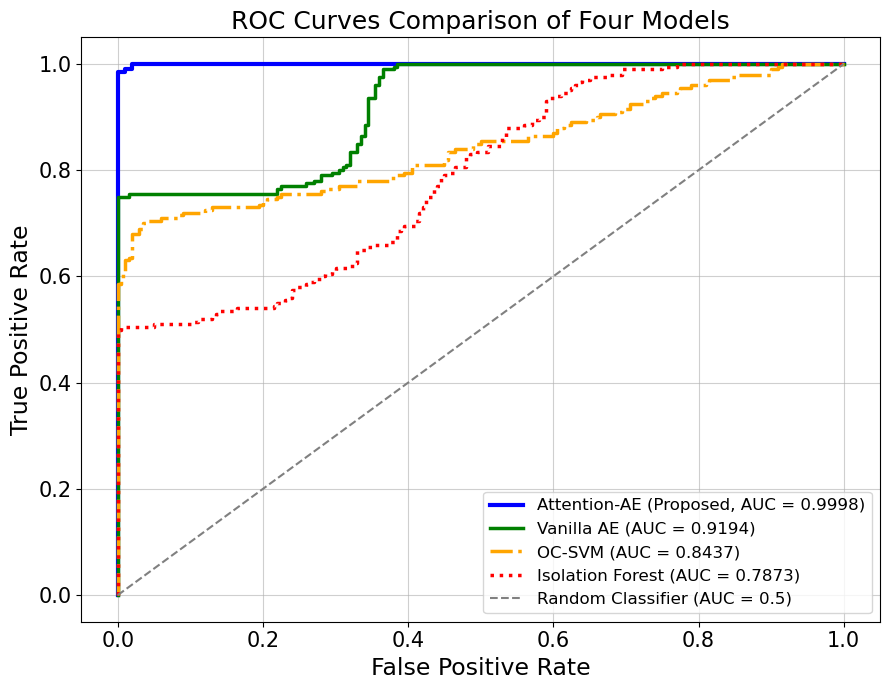


✅ Fig.7 四模型 ROC 对比图已生成！
AUC 排序: Attention-AE (0.9998) > Vanilla AE (0.9194) > OC-SVM (0.8437) > Isolation Forest (0.7873)


In [25]:
# ==================== 四模型 ROC 曲线对比图（终极版） ====================
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

print("=== 生成四模型 ROC 曲线对比图（含 OC-SVM）===")

# ---- 1. 确保已计算四个模型的分数和指标 ----
# 假设您已经运行过所有 Cell，以下变量应已存在：
# scores_att, scores_van, scores_iso, scores_ocsvm, y_test

# ---- 2. 计算四个模型的 ROC 数据 ----
def get_roc_data(scores, y_true):
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

fpr_att, tpr_att, auc_att = get_roc_data(scores_att, y_test)
fpr_van, tpr_van, auc_van = get_roc_data(scores_van, y_test)
fpr_iso, tpr_iso, auc_iso = get_roc_data(scores_iso, y_test)
fpr_ocs, tpr_ocs, auc_ocs = get_roc_data(scores_ocsvm, y_test)

# ---- 3. 绘制四模型对比图 ----
plt.figure(figsize=(9, 7))

# 按性能从高到低排序绘制，颜色区分明显
plt.plot(fpr_att, tpr_att, color='blue', lw=3.0, 
         label=f'Attention-AE (Proposed, AUC = {auc_att:.4f})')
plt.plot(fpr_van, tpr_van, color='green', lw=2.5, 
         label=f'Vanilla AE (AUC = {auc_van:.4f})')
plt.plot(fpr_ocs, tpr_ocs, color='orange', lw=2.5, linestyle='-.', 
         label=f'OC-SVM (AUC = {auc_ocs:.4f})')
plt.plot(fpr_iso, tpr_iso, color='red', lw=2.5, linestyle=':', 
         label=f'Isolation Forest (AUC = {auc_iso:.4f})')

# 随机参考线
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', 
         label='Random Classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate', fontsize=17)
plt.ylabel('True Positive Rate', fontsize=17)
plt.title('ROC Curves Comparison of Four Models', fontsize=18)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.savefig('Fig7_ROC_Comparison_Four_Models.png', dpi=400, bbox_inches='tight')
plt.show()

print("\n✅ Fig.7 四模型 ROC 对比图已生成！")
print(f"AUC 排序: Attention-AE ({auc_att:.4f}) > Vanilla AE ({auc_van:.4f}) > OC-SVM ({auc_ocs:.4f}) > Isolation Forest ({auc_iso:.4f})")

=== 生成 Figure 8a + 8b 异常分数分布对比图 ===



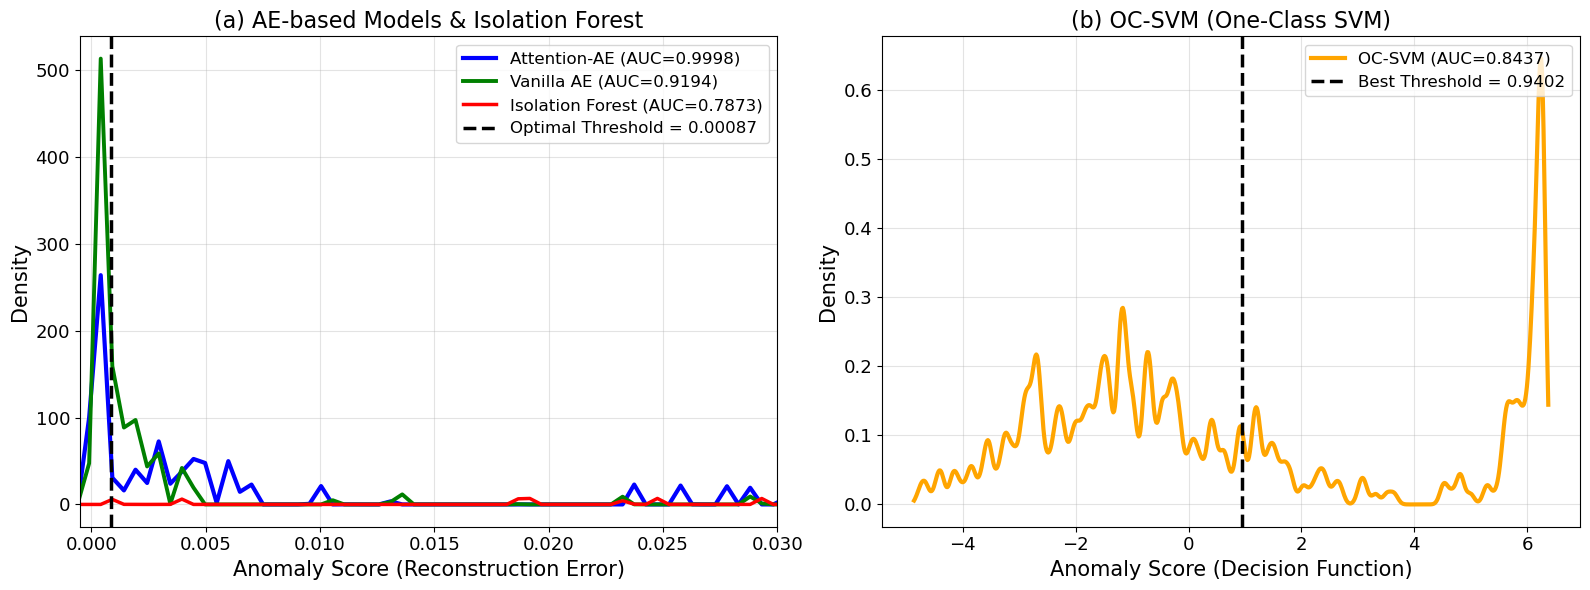

✅ Fig.8a + 8b 已生成并保存为 Fig8_Anomaly_Score_Distribution_Subplots.png

各模型 AUC 排序:
  Attention-AE:  0.9998
  Vanilla AE:    0.9194
  OC-SVM:        0.8437
  Isolation Forest: 0.7873


In [27]:
# ==================== Figure 8: 异常分数分布对比图（分图版） ====================
# Figure 8a: AE类模型 (Attention-AE, Vanilla AE, Isolation Forest) —— 保留您的原图风格
# Figure 8b: OC-SVM 单独展示（附带其最佳阈值）

import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

print("=== 生成 Figure 8a + 8b 异常分数分布对比图 ===\n")

# ---- Figure 8a: 三模型对比（完全保留您的原代码风格） ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ----- 左图 (8a): 三个模型 -----
# 1. 绘制三个模型的密度曲线
kde_att = gaussian_kde(scores_att, bw_method=0.001)
x = np.linspace(min(scores_att.min(), scores_van.min(), scores_iso.min()) - 0.0005,
                max(scores_att.max(), scores_van.max(), scores_iso.max()) + 0.005, 800)
ax1.plot(x, kde_att(x), color='blue', lw=3.0, label=f'Attention-AE (AUC={auc_att:.4f})')

kde_van = gaussian_kde(scores_van, bw_method=0.001)
ax1.plot(x, kde_van(x), color='green', lw=2.8, label=f'Vanilla AE (AUC={auc_van:.4f})')

kde_iso = gaussian_kde(scores_iso, bw_method=0.002)
ax1.plot(x, kde_iso(x), color='red', lw=2.5, label=f'Isolation Forest (AUC={auc_iso:.4f})')

# 标注最佳阈值（沿用您原来的 Attention-AE 阈值 0.00087）
best_threshold = 0.00087
ax1.axvline(x=best_threshold, color='black', linestyle='--', lw=2.5,
            label=f'Optimal Threshold = {best_threshold:.5f}')

# 美化
ax1.set_xlabel('Anomaly Score (Reconstruction Error)', fontsize=15)
ax1.set_ylabel('Density', fontsize=15)
ax1.set_title('(a) AE-based Models & Isolation Forest', fontsize=16)
ax1.legend(fontsize=12, loc='upper right')
ax1.grid(True, alpha=0.35)
ax1.set_xlim(-0.0005, 0.03)
ax1.tick_params(axis='both', which='major', labelsize=13)


# ----- 右图 (8b): OC-SVM 单独展示 -----
# OC-SVM 的分数范围与 AE 完全不同，单独画才能看清分布
kde_ocs = gaussian_kde(scores_ocsvm, bw_method=0.02)
x_ocs = np.linspace(scores_ocsvm.min() - 0.1, scores_ocsvm.max() + 0.1, 800)
ax2.plot(x_ocs, kde_ocs(x_ocs), color='orange', lw=3.0, label=f'OC-SVM (AUC={auc_ocs:.4f})')

# 标注 OC-SVM 自己的最佳阈值
best_threshold_ocs = 0.940163  # 从您之前的输出中获取
ax2.axvline(x=best_threshold_ocs, color='black', linestyle='--', lw=2.5,
            label=f'Best Threshold = {best_threshold_ocs:.4f}')

# 美化
ax2.set_xlabel('Anomaly Score (Decision Function)', fontsize=15)
ax2.set_ylabel('Density', fontsize=15)
ax2.set_title('(b) OC-SVM (One-Class SVM)', fontsize=16)
ax2.legend(fontsize=12, loc='upper right')
ax2.grid(True, alpha=0.35)
ax2.tick_params(axis='both', which='major', labelsize=13)

plt.tight_layout()
plt.savefig('Fig8_Anomaly_Score_Distribution_Subplots.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Fig.8a + 8b 已生成并保存为 Fig8_Anomaly_Score_Distribution_Subplots.png")
print(f"\n各模型 AUC 排序:")
print(f"  Attention-AE:  {auc_att:.4f}")
print(f"  Vanilla AE:    {auc_van:.4f}")
print(f"  OC-SVM:        {auc_ocs:.4f}")
print(f"  Isolation Forest: {auc_iso:.4f}")

=== 生成 Figure 8a + 8b 异常分数分布对比图 ===



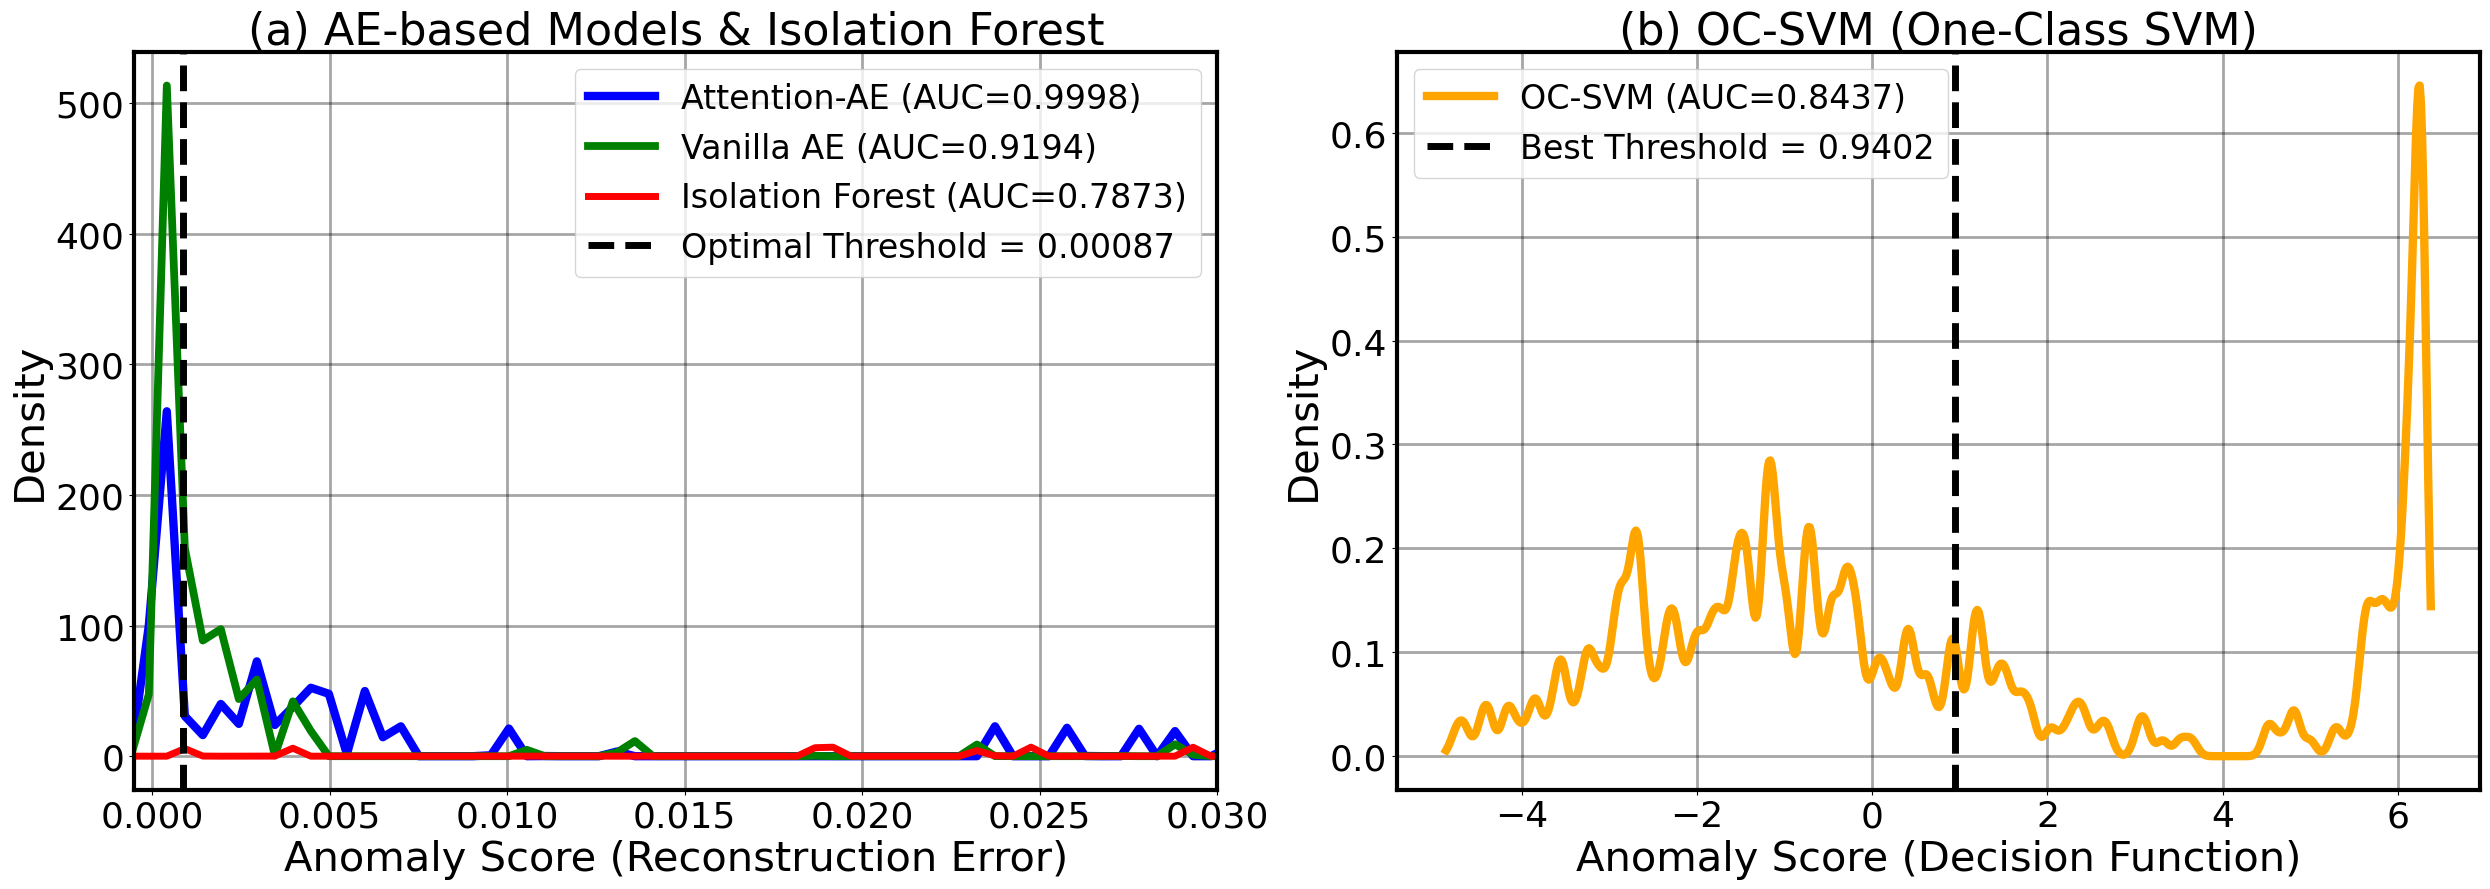

✅ Fig.8a + 8b 已生成并保存为 Fig8_Anomaly_Score_Distribution_Subplots_Enlarged.png

各模型 AUC 排序:
  Attention-AE:  0.9998
  Vanilla AE:    0.9194
  OC-SVM:        0.8437
  Isolation Forest: 0.7873


In [46]:
# ==================== Figure 8: 异常分数分布对比图（分图版） ====================
# Figure 8a: AE类模型 (Attention-AE, Vanilla AE, Isolation Forest)
# Figure 8b: OC-SVM 单独展示

import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

print("=== 生成 Figure 8a + 8b 异常分数分布对比图 ===\n")

# ---- 创建画布 ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 9))

# ----- 左图 (8a): 三个模型 -----
kde_att = gaussian_kde(scores_att, bw_method=0.001)
x = np.linspace(min(scores_att.min(), scores_van.min(), scores_iso.min()) - 0.0005,
                max(scores_att.max(), scores_van.max(), scores_iso.max()) + 0.005, 800)
ax1.plot(x, kde_att(x), color='blue', lw=6.0, label=f'Attention-AE (AUC={auc_att:.4f})')

kde_van = gaussian_kde(scores_van, bw_method=0.001)
ax1.plot(x, kde_van(x), color='green', lw=5.6, label=f'Vanilla AE (AUC={auc_van:.4f})')

kde_iso = gaussian_kde(scores_iso, bw_method=0.002)
ax1.plot(x, kde_iso(x), color='red', lw=5.0, label=f'Isolation Forest (AUC={auc_iso:.4f})')

best_threshold = 0.00087
ax1.axvline(x=best_threshold, color='black', linestyle='--', lw=5.0,
            label=f'Optimal Threshold = {best_threshold:.5f}')

ax1.set_xlabel('Anomaly Score (Reconstruction Error)', fontsize=30)
ax1.set_ylabel('Density', fontsize=30)
ax1.set_title('(a) AE-based Models & Isolation Forest', fontsize=32)
ax1.legend(fontsize=24, loc='upper right')
ax1.grid(True, alpha=0.35, color='black')  # 网格改为黑色
ax1.set_xlim(-0.0005, 0.03)
ax1.tick_params(axis='both', which='major', labelsize=26)

# ----- 右图 (8b): OC-SVM 单独展示 -----
kde_ocs = gaussian_kde(scores_ocsvm, bw_method=0.02)
x_ocs = np.linspace(scores_ocsvm.min() - 0.1, scores_ocsvm.max() + 0.1, 800)
ax2.plot(x_ocs, kde_ocs(x_ocs), color='orange', lw=6.0, label=f'OC-SVM (AUC={auc_ocs:.4f})')

best_threshold_ocs = 0.940163
ax2.axvline(x=best_threshold_ocs, color='black', linestyle='--', lw=5.0,
            label=f'Best Threshold = {best_threshold_ocs:.4f}')

ax2.set_xlabel('Anomaly Score (Decision Function)', fontsize=30)
ax2.set_ylabel('Density', fontsize=30)
ax2.set_title('(b) OC-SVM (One-Class SVM)', fontsize=32)
ax2.legend(fontsize=24, loc='upper left')
ax2.grid(True, alpha=0.35, color='black')  # 网格改为黑色
ax2.tick_params(axis='both', which='major', labelsize=26)

# ----- 统一加粗边框和网格线 -----
for ax in [ax1, ax2]:
    # 加粗边框（spines）
    for spine in ax.spines.values():
        spine.set_linewidth(3.0)
    # 加粗网格线（颜色已在上面单独设置，这里只改线宽）
    ax.grid(True, alpha=0.35, linewidth=2.0, color='black')

plt.tight_layout()
plt.savefig('Fig8_Anomaly_Score_Distribution_Subplots_Enlarged.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Fig.8a + 8b 已生成并保存为 Fig8_Anomaly_Score_Distribution_Subplots_Enlarged.png")
print(f"\n各模型 AUC 排序:")
print(f"  Attention-AE:  {auc_att:.4f}")
print(f"  Vanilla AE:    {auc_van:.4f}")
print(f"  OC-SVM:        {auc_ocs:.4f}")
print(f"  Isolation Forest: {auc_iso:.4f}")